In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow Datasets version: {tfds.__version__}")

TensorFlow version: 2.21.0
TensorFlow Datasets version: 4.9.10


In [4]:
dataset = tfds.load('emnist/balanced', split=['train', 'test'], as_supervised=True)
train_dataset, test_dataset = dataset

Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...: 100%|██████████| 1/1 [00:35<00:00, 33.22s/ url]

Extraction completed...: 100%|██████████| 4/4 [00:00<00:00,  6.71 file/s]
                                                                        

Dataset emnist downloaded and prepared to C:\Users\madha\tensorflow_datasets\emnist\balanced\3.1.0. Subsequent calls will reuse this data.


In [5]:
info = tfds.builder('emnist/balanced').info
num_classes = info.features['label'].num_classes

print(f"Number of classes: {num_classes}")
print(f"Training samples: {info.splits['train'].num_examples}")
print(f"Test samples: {info.splits['test'].num_examples}")
print(f"Image shape: {info.features['image'].shape}")
print(f"Class names: {info.features['label'].names}")

class_labels = info.features['label'].names

Number of classes: 47
Training samples: 112800
Test samples: 18800
Image shape: (28, 28, 1)
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46']


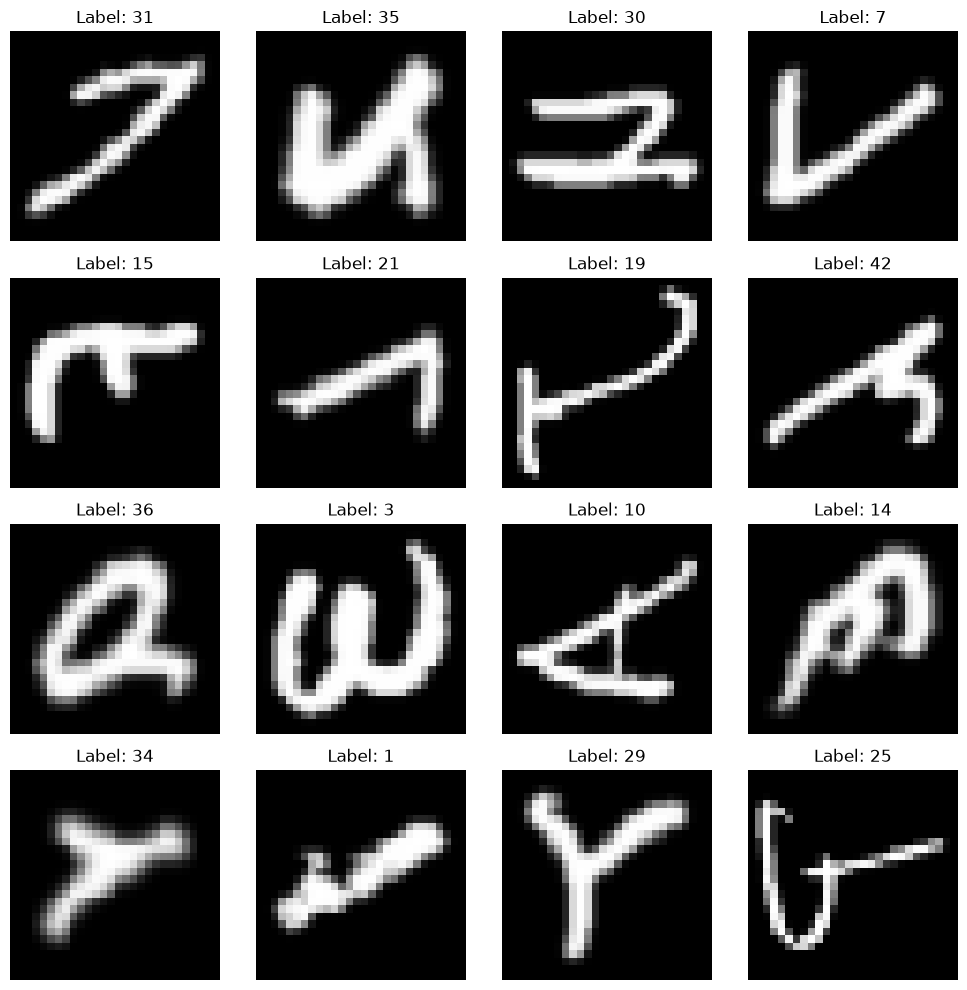

In [ ]:
def show_sample_images(dataset, num_samples=16):
    #Display sample images from the dataset
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    axes = axes.ravel()
    
    for i, (image, label) in enumerate(dataset.take(num_samples)):
        image_np = image.numpy().squeeze()
        axes[i].imshow(image_np, cmap='gray')
        axes[i].set_title(f'Label: {class_labels[label.numpy()]}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

show_sample_images(train_dataset)

In [ ]:
def preprocess_data(image, label):
    #Normalize pixel values to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    #Reshape to add channel dimension (28, 28, 1)
    image = tf.expand_dims(image, axis=-1)
    #One-hot encode labels
    label = tf.one_hot(label, depth=num_classes)
    return image, label

#Apply preprocessing to both train and test datasets
train_dataset_preprocessed = train_dataset.map(preprocess_data)
test_dataset_preprocessed = test_dataset.map(preprocess_data)

In [8]:
BATCH_SIZE = 64
BUFFER_SIZE = 10000

#Prepare training dataset
train_dataset_final = train_dataset_preprocessed.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#Prepare test dataset
test_dataset_final = test_dataset_preprocessed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
def create_cnn_model():
    model = tf.keras.Sequential([
        #Convolutional layers
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),
        
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),
        
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),
        
        #Flatten and Dense layers
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        
        #Output layer with softmax activation
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

model = create_cnn_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,095 (1.17 MB)

 Trainable params: 304,111 (1.16 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [10]:
def compile_model():
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

compile_model()


In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]
EPOCHS = 30

history = model.fit(
    train_dataset_final,
    epochs=EPOCHS,
    validation_data=test_dataset_final,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
1763/1763 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.5334 - loss: 1.5909 - val_accuracy: 0.7710 - val_loss: 0.6630 - learning_rate: 0.0010
Epoch 2/30
1763/1763 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.7217 - loss: 0.8399 - val_accuracy: 0.8054 - val_loss: 0.5569 - learning_rate: 0.0010
Epoch 3/30
1763/1763 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.7573 - loss: 0.7243 - val_accuracy: 0.8247 - val_loss: 0.5049 - learning_rate: 0.0010
Epoch 4/30
1763/1763 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.7743 - loss: 0.6695 - val_accuracy: 0.8324 - val_loss: 0.4840 - learning_rate: 0.0010
Epoch 5/30
1763/1763 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.7852 - loss: 0.6344 - val_accuracy: 0.8360 - val_loss: 0.4649 - learning_rate: 0.0010
Epoch 6/30
1763/1763 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.7926 - loss: 0.6094 - val_accuracy: 0.8447 - val_loss: 0.4430 - learning_rate: 0.0010
Epoch 7/30
1763/1763 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accura

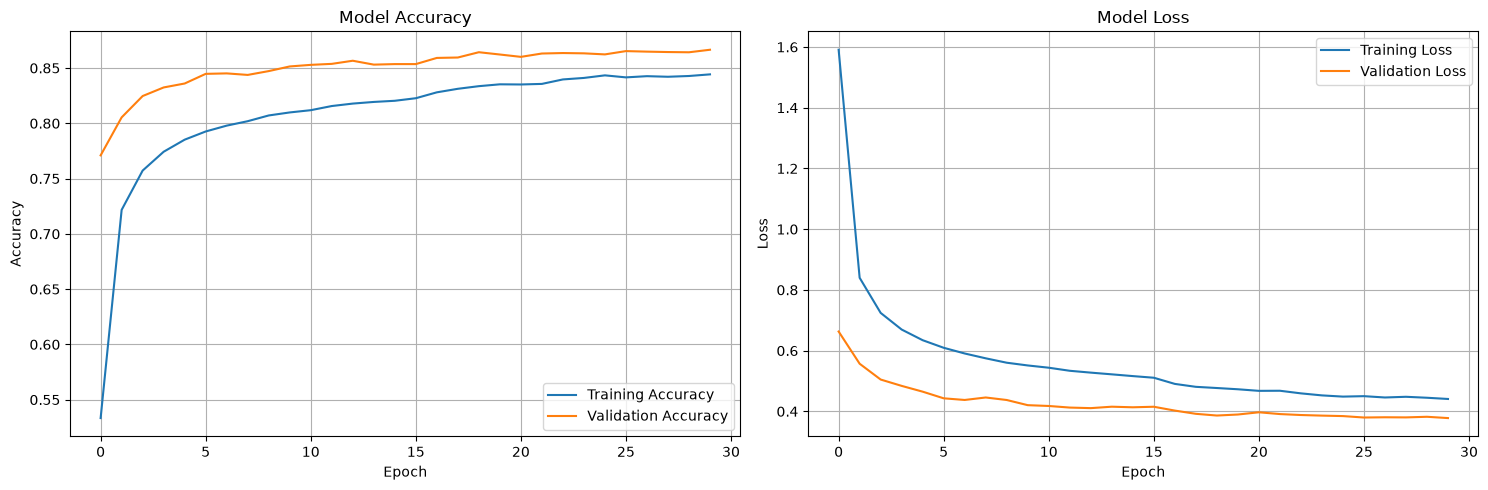

In [13]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss plot
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Model Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [14]:
test_loss, test_accuracy = model.evaluate(test_dataset_final, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.8665
Test Loss: 0.3780


In [15]:
def get_predictions(model, dataset):
    all_labels = []
    all_predictions = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)
        true_classes = np.argmax(labels.numpy(), axis=1)
        
        all_labels.extend(true_classes)
        all_predictions.extend(predicted_classes)
    
    return np.array(all_labels), np.array(all_predictions)

true_labels, predicted_labels = get_predictions(model, test_dataset_final)


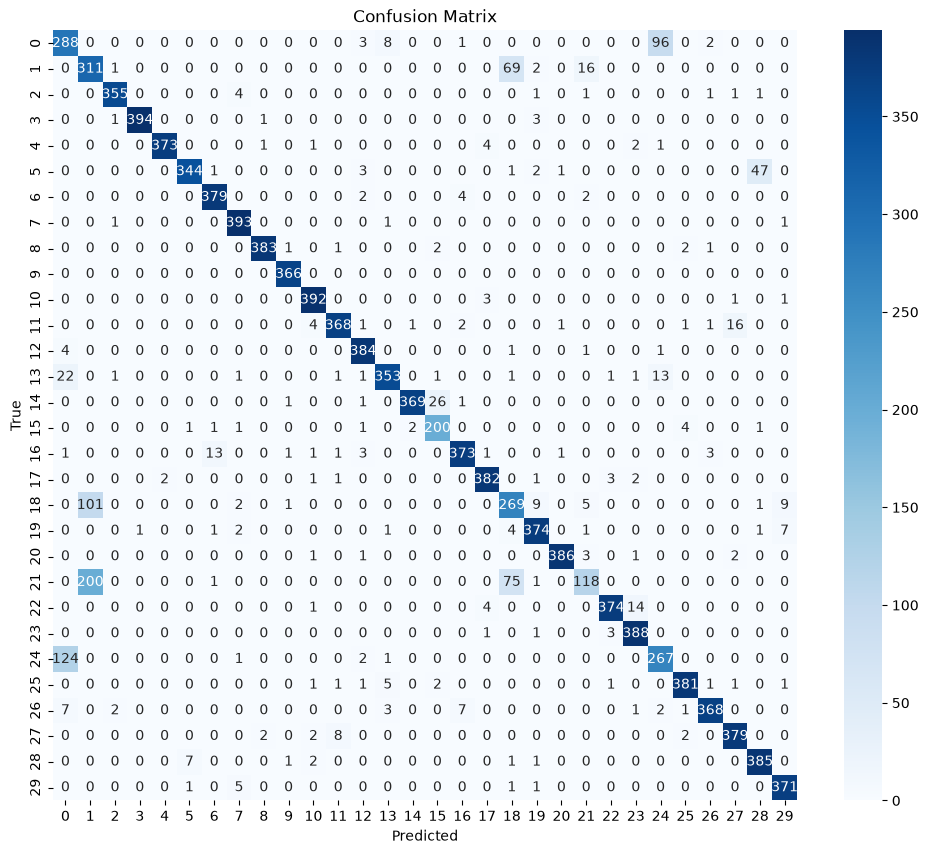

In [16]:
def plot_confusion_matrix(true_labels, predicted_labels, class_names, max_classes=30):
    cm = confusion_matrix(true_labels, predicted_labels)
    
    #Limit to first N classes for visualization
    if max_classes:
        cm = cm[:max_classes, :max_classes]
        class_names = class_names[:max_classes]
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

#Plot confusion matrix (showing first 30 classes for readability)
plot_confusion_matrix(true_labels, predicted_labels, class_labels, max_classes=30)

Sample 0: True=36, Pred=36, Confidence=98.88%
Sample 1: True=11, Pred=11, Confidence=99.91%
Sample 2: True=31, Pred=31, Confidence=99.54%
Sample 3: True=44, Pred=44, Confidence=97.37%
Sample 4: True=46, Pred=46, Confidence=98.04%


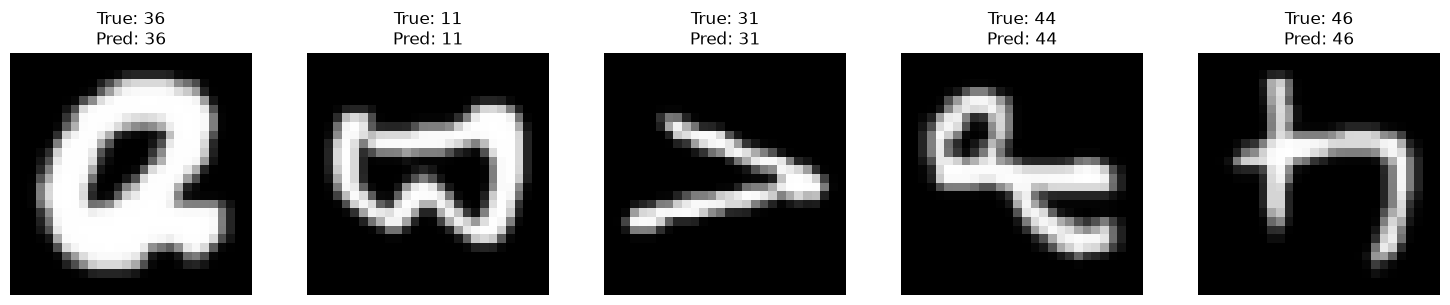

Sample 0: True=32, Pred=32, Confidence=99.92%
Sample 1: True=40, Pred=40, Confidence=70.42%
Sample 2: True=32, Pred=32, Confidence=99.99%
Sample 3: True=16, Pred=16, Confidence=89.51%
Sample 4: True=42, Pred=42, Confidence=91.38%


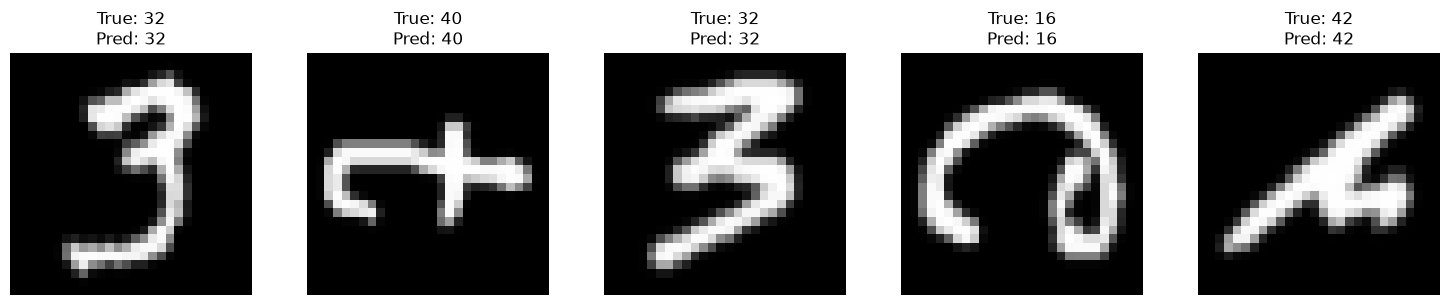

Sample 0: True=0, Pred=0, Confidence=71.21%
Sample 1: True=13, Pred=7, Confidence=74.70%
Sample 2: True=28, Pred=28, Confidence=92.38%
Sample 3: True=42, Pred=44, Confidence=31.89%
Sample 4: True=42, Pred=42, Confidence=93.48%


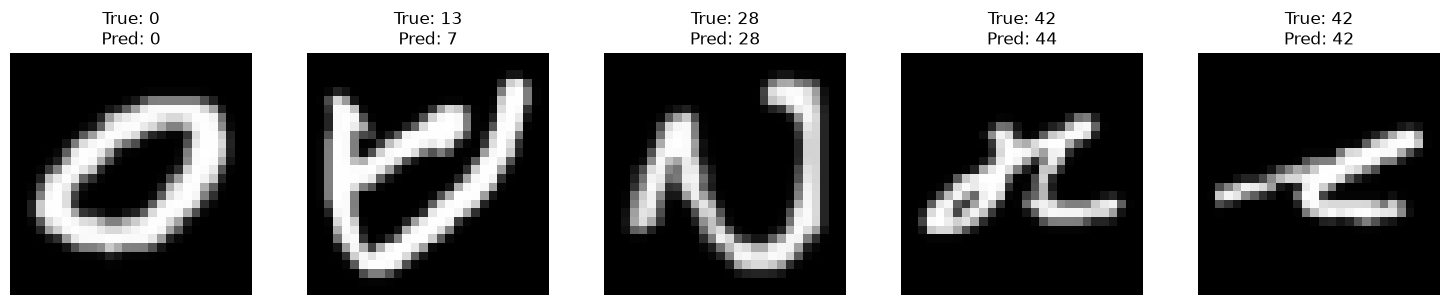

Sample 0: True=15, Pred=15, Confidence=55.08%
Sample 1: True=3, Pred=3, Confidence=99.91%
Sample 2: True=29, Pred=29, Confidence=99.53%
Sample 3: True=42, Pred=42, Confidence=90.92%
Sample 4: True=37, Pred=37, Confidence=94.49%


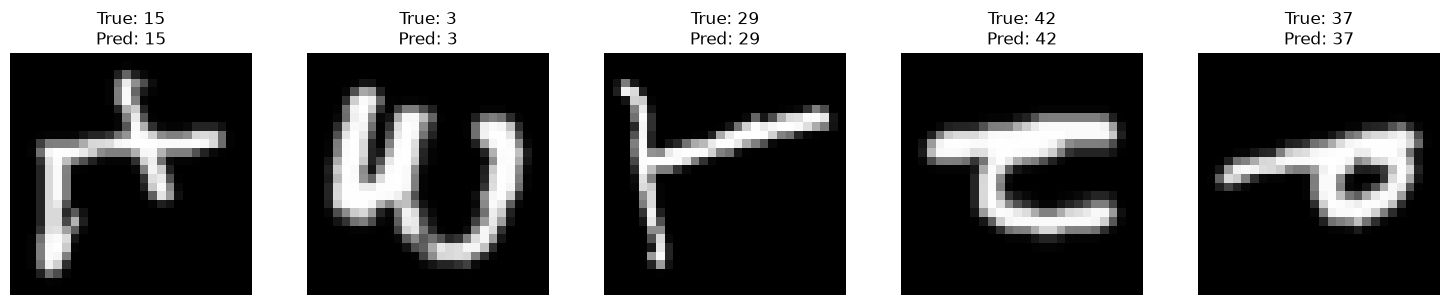

Sample 0: True=22, Pred=22, Confidence=96.86%
Sample 1: True=45, Pred=45, Confidence=99.92%
Sample 2: True=8, Pred=26, Confidence=55.65%
Sample 3: True=23, Pred=23, Confidence=72.49%
Sample 4: True=32, Pred=32, Confidence=99.39%


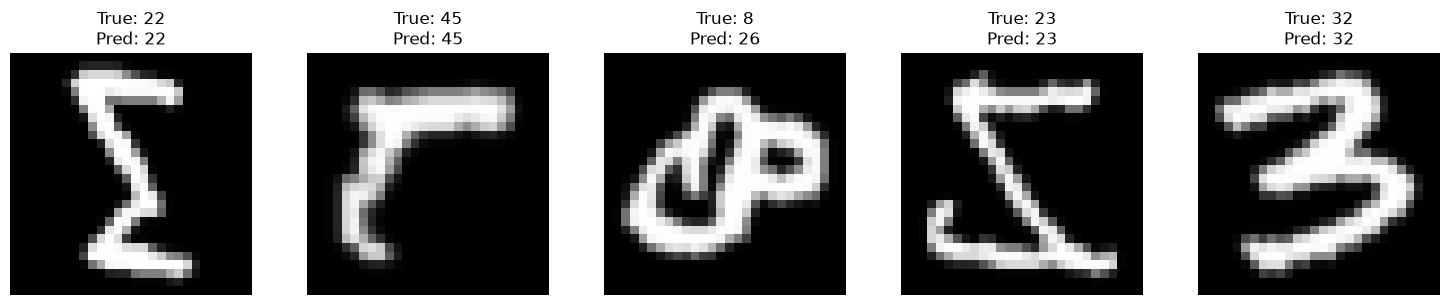

In [23]:
def test_with_emnist_images():
    #Get a batch of test images
    for images, labels in test_dataset_final.take(5):
        #Get predictions
        predictions = model.predict(images, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)
        true_classes = np.argmax(labels.numpy(), axis=1)
        
        #Display results
        fig, axes = plt.subplots(1, 5, figsize=(15, 3))
        for i in range(5):
            axes[i].imshow(images[i].numpy().squeeze(), cmap='gray')
            true_name = class_labels[true_classes[i]] if true_classes[i] < len(class_labels) else str(true_classes[i])
            pred_name = class_labels[predicted_classes[i]] if predicted_classes[i] < len(class_labels) else str(predicted_classes[i])
            axes[i].set_title(f'True: {true_name}\nPred: {pred_name}')
            axes[i].axis('off')
            confidence = np.max(predictions[i])
            print(f"Sample {i}: True={true_name}, Pred={pred_name}, Confidence={confidence:.2%}")
        plt.tight_layout()
        plt.show()

test_with_emnist_images()